In [151]:
from moabb.paradigms import LeftRightImagery
from moabb.datasets import *
from mne.decoding import Scaler
from hoda.tensorize import Tensorize

dataset= Zhou2016()
paradigm = LeftRightImagery(
    resample=None
)

epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
    subjects=[1],
    return_epochs=True,
)

session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


Reading 0 ... 305029  =      0.000 ...  1220.116 secs...


/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])


Reading 0 ... 430479  =      0.000 ...  1721.916 secs...


/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])


Reading 0 ... 252599  =      0.000 ...  1010.396 secs...


...

/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])


Reading 0 ... 226219  =      0.000 ...   904.876 secs...


/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])
/usr/local/lib/python3.10/dist-packages/moabb/datasets/Zhou2016.py:111: RuntimeWarning: Could not define the number of bytes automatically. Defaulting to 2.
  raw = read_raw_cnt(fname, preload=True, eog=["VEOU", "VEOL"])


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
319 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 60 events (all good), 0 – 5 s (baseline off), ~8.0 MB, data loaded,
 'left_hand': 30
 'right_hand': 30>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 59 events (all good), 0 – 5 s (baseline off), ~7.9 MB, data loaded,
 'left_hand': 30
 'right_hand': 29>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 50 events (all good), 0 – 5 s (baseline off), ~6.7 MB, data loaded,
 'left_hand': 25
 'right_hand': 25>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:279: UserWarning: warnEpochs <Epochs | 50 events (all good), 0 – 5 s (baseline off), ~6.7 MB, data loaded,
 'left_hand': 25
 'right_hand': 25>
  warn(f"warnEpochs {epochs}")
/usr/local/lib/p

In [152]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


No projector specified for this dataset. Please consider the method self.add_proj.


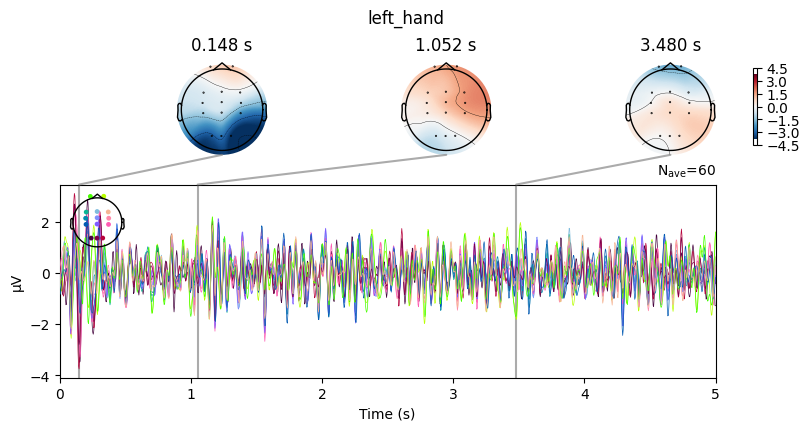

No projector specified for this dataset. Please consider the method self.add_proj.


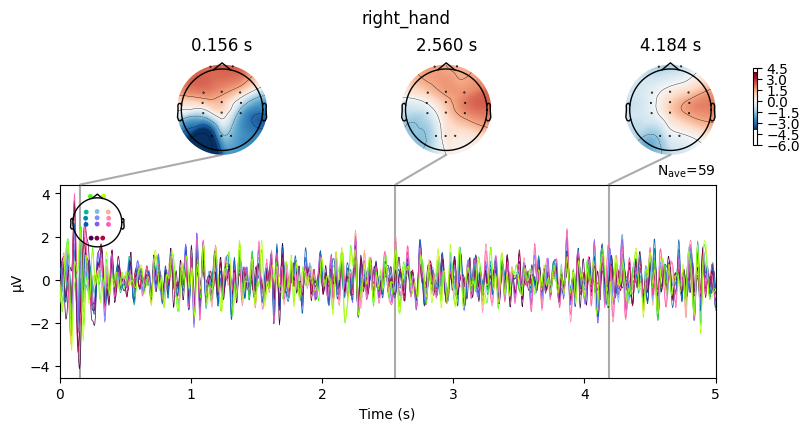

In [153]:
import numpy as np
ts_args=dict(ylim=dict(
    #eeg=[-15,15]
))
joint_args=dict(ts_args=ts_args)
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

In [156]:
from hoda.tensorize import stf_tensor
from sklearn.preprocessing import StandardScaler
import tensorly as tl
from mne.decoding import Scaler

X = epochs.get_data()
y = labels
X = Scaler(scalings='mean', with_mean=True).fit_transform(X)
X = stf_tensor(X, sfreq=epochs.info['sfreq'], baseline_params=dict(baseline=(.1,.4), mode="logratio"))
X = tl.tensor(X)
X.shape

(119, 14, 16, 80)

<Axes: >

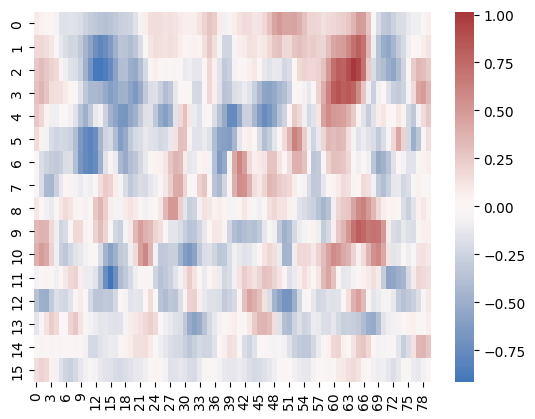

In [157]:
import seaborn as sns
contrast = tl.to_numpy(X[y=='right_hand'].mean(axis=0)) - tl.to_numpy(X[y=='left_hand'].mean(axis=0))
sns.heatmap(contrast[3], cmap="vlag", center=0)

<Axes: >

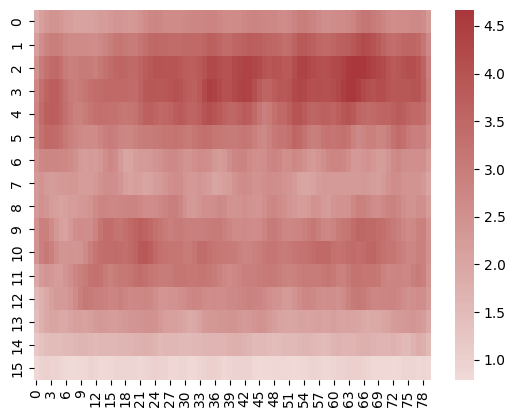

In [158]:
sns.heatmap(tl.to_numpy(X[y=='right_hand'].mean(axis=0))[3], cmap="vlag", center=0 )

<Axes: >

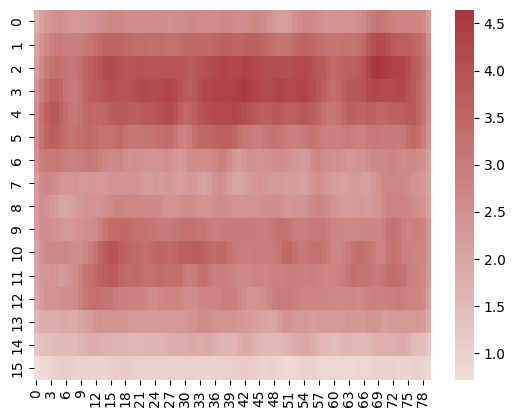

In [159]:
sns.heatmap(tl.to_numpy(X[y=='left_hand'].mean(axis=0))[3], cmap="vlag", center=0 )

/tmp/ipykernel_6062/686525531.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x)


<Axes: ylabel='Density'>

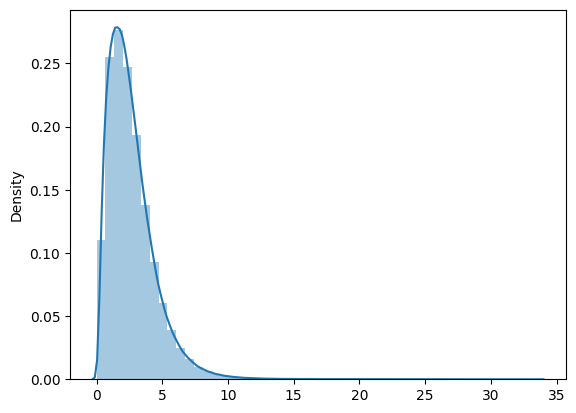

In [171]:
x = X[:,:,:,:].flatten()
x = tl.to_numpy(x)
sns.distplot(x)

In [172]:
from hoda.hoda import HODA

hoda = HODA(
        rank=1,
        max_iter=128,
        tol=0,
        init ='eye',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
        random_state=42,
        delta=None,
        forward=True,
)


In [173]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')

hoda.fit_backward(X,y)
df = pd.DataFrame(hoda.train_info_['backward'])
display(df)

Backward HODA model rank=(1, 1, 1): 100%|██████████| 128/128 [00:02<00:00, 55.59it/s]


,iteration,mode,update,shrinkage,rank,objective
0,1,0,1.319846e+00,0.086005,1,1.364746e+06
1,1,1,1.179912e+00,0.058334,1,9.085483e+05
2,1,2,1.216224e+00,0.151206,1,3.237333e+05
3,2,0,8.848813e-01,0.055537,1,1.567281e+06
4,2,1,5.090095e-01,0.064996,1,7.324699e+05
...,...,...,...,...,...,...
379,127,1,9.744167e-10,0.077426,1,4.882926e+05
380,127,2,1.197055e-09,0.215558,1,2.145859e+05
381,128,0,1.028352e-09,0.061123,1,3.072414e+05
382,128,1,8.382121e-10,0.077426,1,4.882926e+05


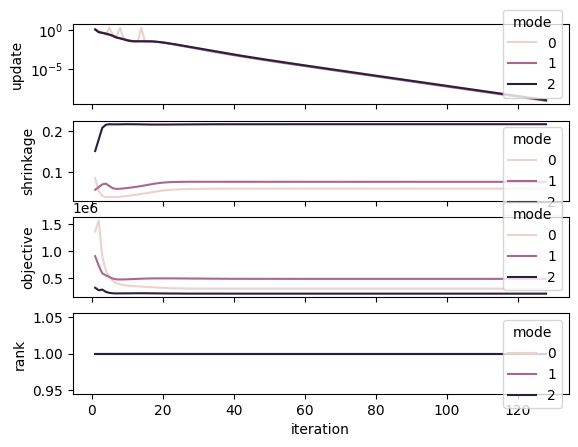

In [174]:
fig, axs = plt.subplots(4,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=df, x='iteration', y='objective',hue='mode', ax=axs[2])
sns.lineplot(data=df, x='iteration', y='rank',hue='mode', ax=axs[3])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='F_tr', ax=axs[0])
    sns.lineplot(data=df, x=df.index, y='F_rt', ax=axs[1])

In [175]:
hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
display(df)


Forward model : 100%|██████████| 128/128 [00:00<00:00, 186.13it/s]


,iteration,mode,update,shrinkage
0,0,0,inf,NaN
1,0,1,inf,NaN
2,0,2,inf,NaN
3,1,0,1.809622e+00,0.0
4,1,1,5.893148e+00,0.0
...,...,...,...,...
379,126,1,1.777689e-16,0.0
380,126,2,1.467090e-16,0.0
381,127,0,1.160268e-16,0.0
382,127,1,5.213860e-17,0.0


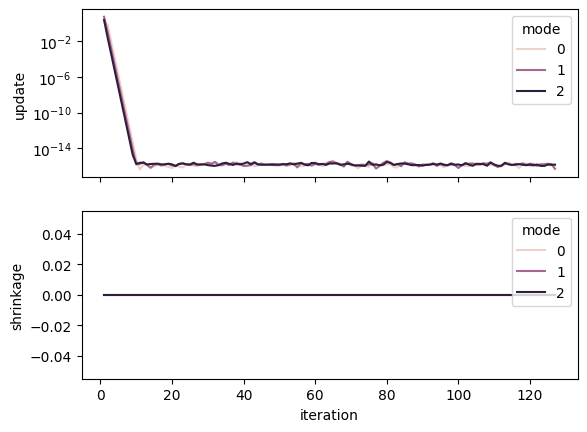

In [176]:

fig, axs = plt.subplots( 2,1, sharex=True)
sns.lineplot(data=df, x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=df, x='iteration', y='shrinkage',hue='mode', ax=axs[1])
if hoda.extra_train_info:
    fig, axs = plt.subplots(2,1, sharex=True)
    sns.lineplot(data=df, x=df.index, y='nmse', ax=axs[0], hue='mode')
    axs[0].set_yscale('log')


In [177]:
#G_cov = tl.tensordot(G.T, G, axes=1)/(n_samples-1)
n_samples = len(X)
Xt = hoda.transform(X)

Xt_flat = tl.to_numpy(Xt.reshape(n_samples, -1))
if Xt_flat.shape[-1] > 1:
    sns.heatmap(np.corrcoef(Xt_flat, rowvar=False),  cmap='vlag', center=0)

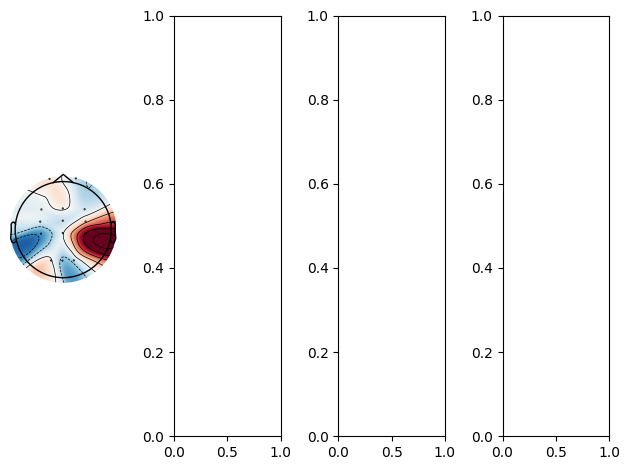

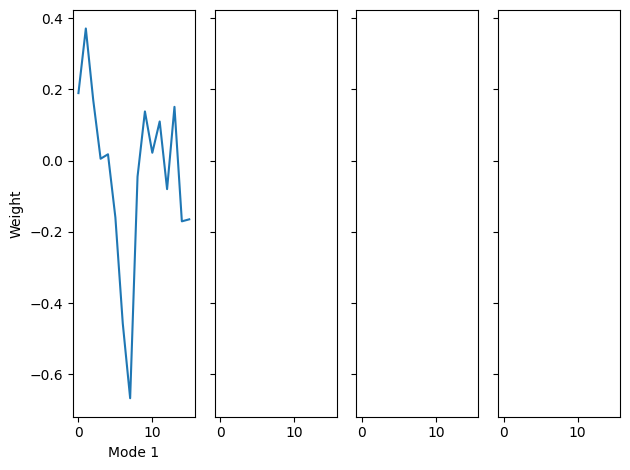

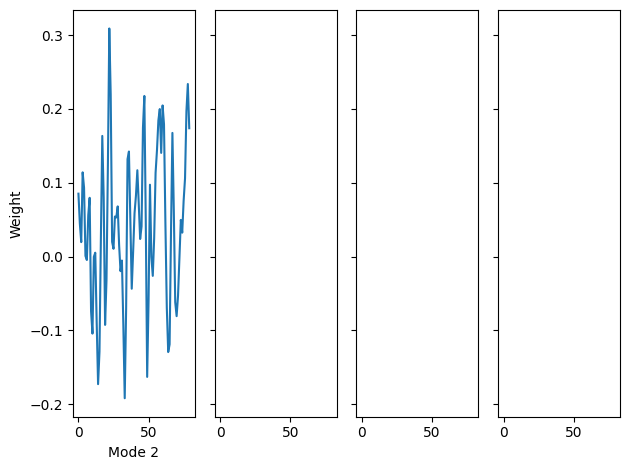

In [178]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4


n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

order = X.ndim-1
for k in range(1, order):
    n_row = int( np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
    for i in range(hoda.rank_[k]):
        w = tl.to_numpy(hoda.weights_[k][:,i])
        axs.flatten()[i].plot(w)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Weight');

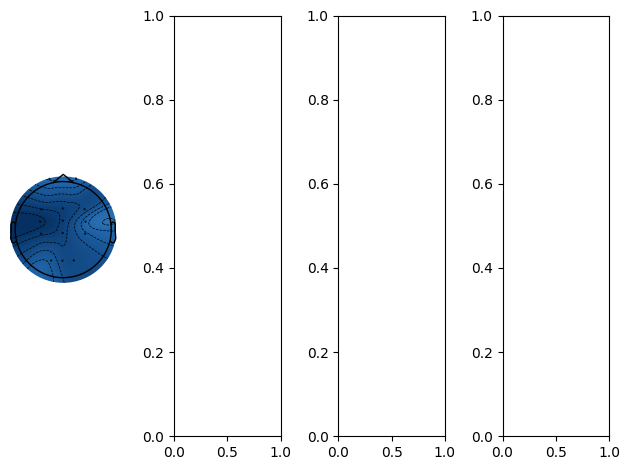

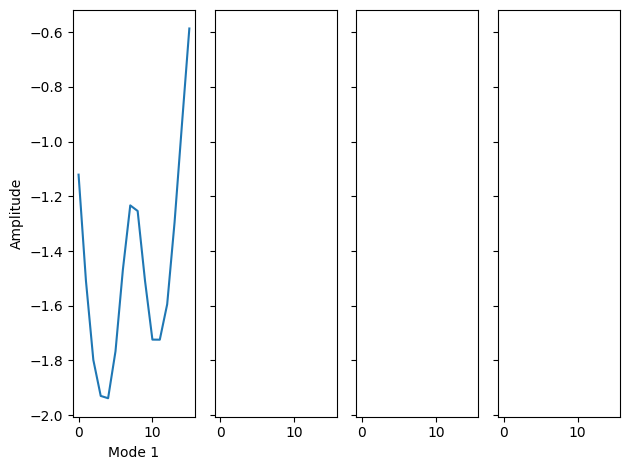

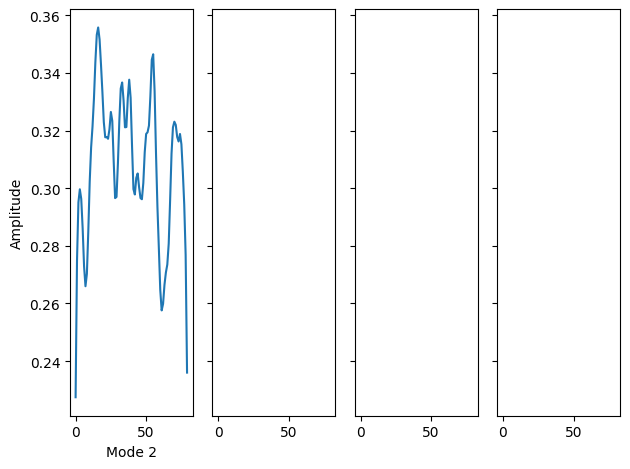

In [179]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

for k in range(1, order):
    n_row = int(np.ceil(hoda.rank_[k] / col_wrap)) 
    fig, axs = plt.subplots(
        n_row, n_col, 
        layout='tight', 
        sharex=True,
        sharey=True
    )
    A = hoda.aps_[k]
    for i in range(hoda.rank_[k]):
        a = tl.to_numpy(A[:,i])
        axs.flatten()[i].plot(a)
        axs.flatten()[i].set_xlabel(f'Mode {k}')
        axs.flatten()[i].sharey(axs.flatten()[0])
    axs.flatten()[0].set_ylabel('Amplitude');

In [180]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=False)
    Xt_viz = decomp.fit_transform(Xt_flat)
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',)
    ax = plt.gca()    
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


<Axes: >

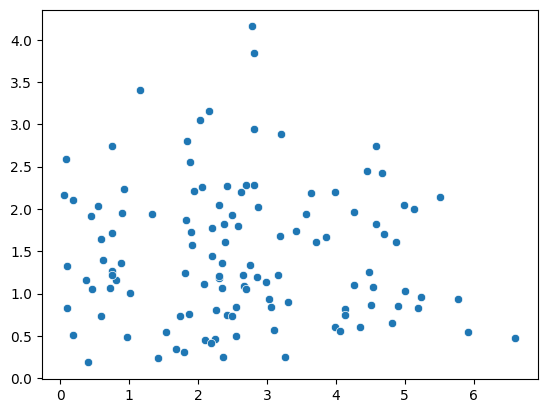

In [182]:
Xt = hoda.transform(X)
sns.scatterplot(x=tl.to_numpy(tl.abs(Xt[:,0,0,0])), y=tl.to_numpy(X[:,0,0,0]))